In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [2]:
red = pd.read_csv("http://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv", sep=';')
white = pd.read_csv("http://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv", sep=';')

red['type'] = 1
white['type'] = 0

wines = pd.concat([red, white], ignore_index=True)
wines.dropna(inplace=True)
wines.to_csv("wines.csv")


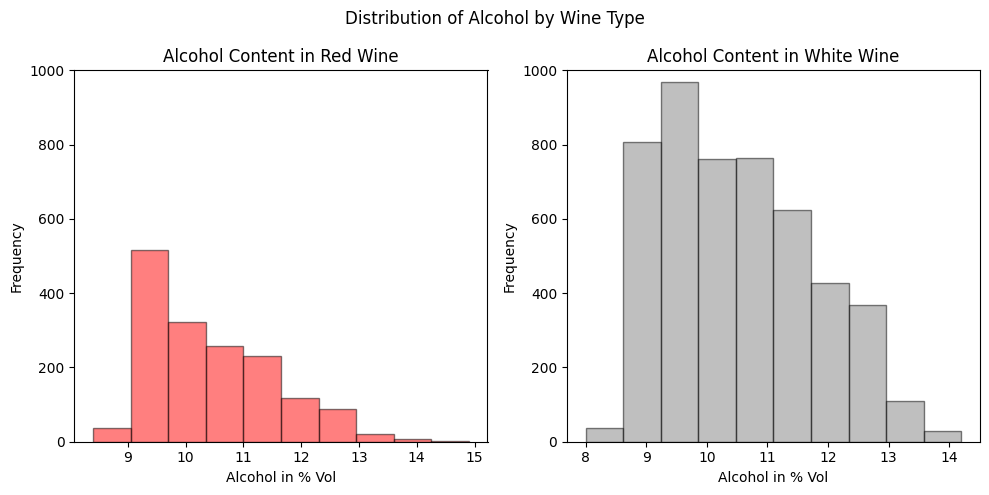

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].hist(wines[wines['type'] == 1].alcohol, bins=10, facecolor='red', alpha=0.5, label='Red wine',edgecolor = 'black',lw =1)
ax[1].hist(wines[wines['type'] == 0].alcohol, bins=10, facecolor='grey', edgecolor='black', lw=1, alpha=0.5, label='White wine')

for a in ax:
    a.set_ylim([0, 1000])
    a.set_xlabel('Alcohol in % Vol')
    a.set_ylabel('Frequency')

ax[0].set_title('Alcohol Content in Red Wine')
ax[1].set_title('Alcohol Content in White Wine')

fig.suptitle('Distribution of Alcohol by Wine Type')
plt.tight_layout()
plt.show()

In [4]:
X = wines.iloc[:, :-1]
y = wines['type']

In [5]:

# --- Data Splitting ---
# Split into training, validation, and testing sets
x_train, x_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.2, random_state = 100) # Use 20% for temp
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size = 0.5, random_state = 100) # Split temp into val and test (10% each)

print(f'Training data shape: {x_train.shape}, {y_train.shape}')
print(f'Validation data shape: {x_val.shape}, {y_val.shape}')
print(f'Testing data shape: {x_test.shape}, {y_test.shape}')

# Convert data to PyTorch tensors
x_train_tensor = torch.tensor(x_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
x_val_tensor = torch.tensor(x_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1, 1)
x_test_tensor = torch.tensor(x_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

# Create DataLoader for batch training
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

batch_size = 32 # Experiment with different batch sizes
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

Training data shape: (5197, 12), (5197,)
Validation data shape: (650, 12), (650,)
Testing data shape: (650, 12), (650,)


In [6]:
# --- Define the neural network model with Dropout ---
class Net(nn.Module):
    def __init__(self, input_features):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(input_features, 12)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.2) # Add dropout
        self.fc2 = nn.Linear(12, 9)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2) # Add dropout
        self.fc3 = nn.Linear(9, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

# Instantiate the model
input_features = x_train.shape[1]
model = Net(input_features)

# Define loss function and optimizer (add weight_decay for L2 regularization)
criterion = nn.BCEWithLogitsLoss()  # Binary Cross Entropy with Logits for binary classification
optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5) # Adjusted learning rate

# --- Training loop with validation ---
epochs = 1000 # Increased epochs
train_loss_history = []
val_loss_history = []

for epoch in range(epochs):
    model.train() # Set the model to training mode
    running_loss = 0.0
    for inputs, targets in train_loader:
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_loss_history.append(train_loss)

    # Evaluate on validation set
    model.eval() # Set the model to evaluation mode
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

    val_loss = val_loss / len(val_loader)
    val_loss_history.append(val_loss)

    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

# --- Evaluate the model on the test set ---
model.eval()  # Set the model to evaluation mode
test_loss = 0.0
with torch.no_grad():
    for inputs, targets in test_loader:
        test_outputs = model(inputs)
        loss = criterion(test_outputs, targets)
        test_loss += loss.item()

test_loss = test_loss / len(test_loader)
print(f'Final Test Loss: {test_loss:.4f}')

Epoch [100/1000], Train Loss: 0.0888, Val Loss: 0.0649
Epoch [200/1000], Train Loss: 0.0825, Val Loss: 0.0496
Epoch [300/1000], Train Loss: 0.0721, Val Loss: 0.0460
Epoch [400/1000], Train Loss: 0.0737, Val Loss: 0.0477
Epoch [500/1000], Train Loss: 0.0753, Val Loss: 0.0438
Epoch [600/1000], Train Loss: 0.0807, Val Loss: 0.0474
Epoch [700/1000], Train Loss: 0.0651, Val Loss: 0.0501
Epoch [800/1000], Train Loss: 0.0705, Val Loss: 0.0507
Epoch [900/1000], Train Loss: 0.0720, Val Loss: 0.0563
Epoch [1000/1000], Train Loss: 0.0648, Val Loss: 0.0602
Final Test Loss: 0.0734


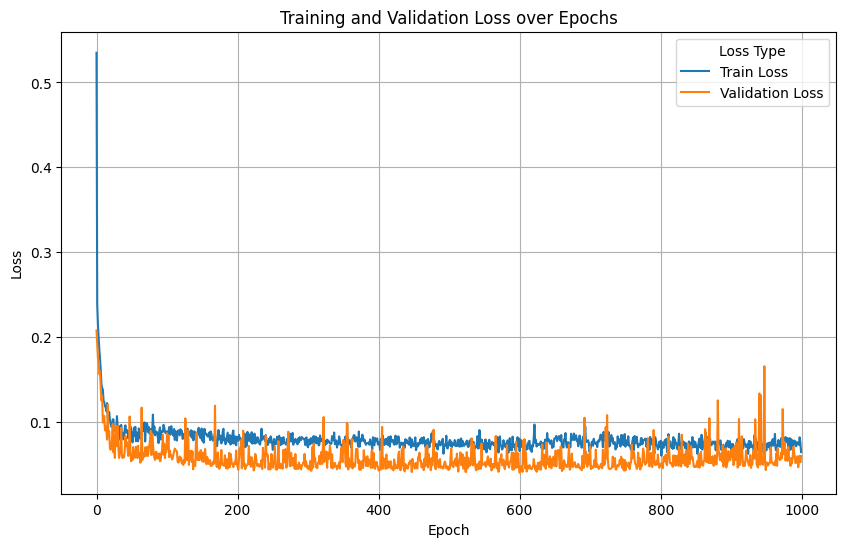

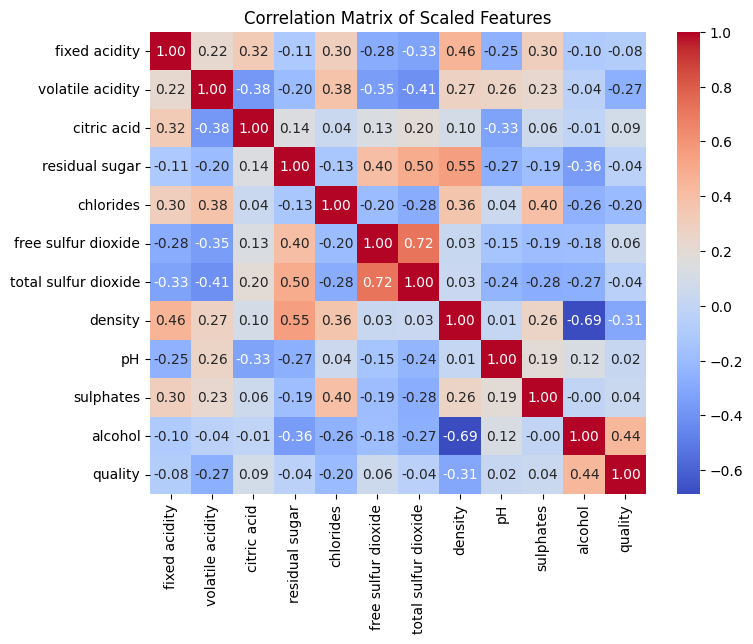

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- Ensure your data is defined here ---
# The following variables are assumed to be pre-existing:
# train_loss_history: A list or NumPy array of training loss values.
# val_loss_history: A list or NumPy array of validation loss values.
# X: A Pandas DataFrame containing the features for the correlation matrix.
# epochs: An integer representing the number of epochs.


# --- Plot 1: Training and Validation Loss (Line Plot) ---

# For Seaborn, it's best to have the data in a "long-form" DataFrame.
loss_df = pd.DataFrame({
    'Epoch': list(range(epochs)) * 2,
    'Loss': np.concatenate([train_loss_history, val_loss_history]),
    'Loss Type': ['Train Loss'] * epochs + ['Validation Loss'] * epochs
})

# Create the plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=loss_df, x='Epoch', y='Loss', hue='Loss Type')

# Add title and labels
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()


# --- Plot 2: Correlation Matrix (Heatmap) ---

# Calculate the correlation matrix
correlation_matrix = X.corr()

# Create the plot
plt.figure(figsize=(8, 6))
# annot=True displays the correlation values on the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

# Add title
plt.title('Correlation Matrix of Scaled Features')
plt.show()